In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import tqdm
import functools
import pandas as pd
from functools import partial
import time
from scipy.integrate import odeint
import torch.utils.data as data
import copy
import math
import filterpy
from filterpy.kalman import EnsembleKalmanFilter
import pandas as pd
import ensemble_kalman_filter_LSTM
from ensemble_kalman_filter_LSTM import *

# Lorenz96 system definition
def lorenz96(x, t, F = 8.0):
    """Lorenz 96 model with constant forcing"""
    return (np.roll(x, -1) - np.roll(x, 2)) * np.roll(x, 1) - x + F 


def initial_state_gen(N, lower_bound = 0, upper_bound = 1):
    if upper_bound <= lower_bound:
        return np.ones(N)
    return np.random.uniform(lower_bound, upper_bound, N)

def lorenz96_solver(initial_state, terminal_time, time_step, F = 8.0):
    t = np.arange(0.0, terminal_time, time_step)
    #sol = solve_ivp(lorenz96, [t[0], t[-1]], initial_state, t_eval = t)
    #return sol
    sol = odeint(lorenz96, initial_state, t)
    return t, sol

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(data.shape[0] - seq_len):
        X.append(data[i:i+seq_len, :])
        y.append(data[i+seq_len, :])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

def create_data(data, LSTM_seq_len, device):
    data_input, data_output = create_sequences(data, LSTM_seq_len)
    data_input = data_input.to(device)
    #data_input = data_input.transpose(-2,-1).to(device)
    data_output = data_output.to(device)
    return data_input, data_output

class LSTMModel(nn.Module):
    def __init__(self, input_dim=3, output_dim=3, hidden_dim=128, num_layers=5):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)

def training_LSTM(model, epochs, optimizer, loss_fn, data_input, data_output, batch_size = 128):
    loader = data.DataLoader(data.TensorDataset(data_input, data_output), shuffle=True, batch_size = batch_size)
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in loader:  
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        if (epoch + 1) % 250 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")


def training_LSTM_main(initial_state, x_dim, time_step, terminal_time, LSTM_seq_len, model, epochs, optimizer, loss_fn, batch_size = 128, F = 8.0, device = 'cpu'):
    t, sol = lorenz96_solver(initial_state, terminal_time, time_step, F)
    data_input, data_output = create_data(sol, LSTM_seq_len, device)
    #current = time.time()
    training_LSTM(model, epochs, optimizer, loss_fn, data_input, data_output, batch_size)
    #print(f"Training time: {time.time() - current}s")

def training_LSTM_inaccurate(initial_state, x_dim, time_step, terminal_time, LSTM_seq_len, model, epochs, optimizer, loss_fn, noise_std = 1, batch_size = 128, F = 8.0, device = 'cpu'):
    t, sol = lorenz96_solver(initial_state, terminal_time, time_step, F)
    data_input, data_output = create_data(sol, LSTM_seq_len, device)
    data_output = data_output + torch.randn_like(data_output) * noise_std
    training_LSTM(model, epochs, optimizer, loss_fn, data_input, data_output, batch_size)

def LSTM_plotting(initial_state, x_dim, time_step, terminal_time, LSTM_seq_len, model, F = 8.0, device = 'cpu'):
    t, sol = lorenz96_solver(initial_state, terminal_time, time_step, F)
    data_input, data_output = create_data(sol, LSTM_seq_len, device)
    model.eval()
    with torch.no_grad():
        predictions = model(data_input).cpu().numpy()

    for i in range(dim_x):
        if_plot = np.random.randint(2)
        if if_plot:
            plt.plot(t[LSTM_seq_len: ], sol[LSTM_seq_len: , i], label = 'dim ' + str(i + 1), color = 'blue')
            plt.plot(t[LSTM_seq_len: ], predictions[:, i],  label = 'prediction', color = 'red')
            plt.legend(loc = 'upper right')
            plt.show()

def testing_dataset_MSE(initial_state, x_dim, time_step, terminal_time, LSTM_seq_len, model, F = 8.0, device = 'cpu'):
    t, sol = lorenz96_solver(initial_state, terminal_time, time_step, F)
    data_input, data_output = create_data(sol, LSTM_seq_len, device)
    model.eval()
    with torch.no_grad():
        predictions = model(data_input).cpu()

    return loss_fn(predictions, torch.Tensor(sol[LSTM_seq_len:, :]))

def EnKF_forward_LSTM(x, x_queue, dt):
    torch_x = torch.from_numpy(x).reshape([ensemble_size, 1, dim_x]).to(torch.float).to(device)
    torch_queue = torch.from_numpy(x_queue.reshape(ensemble_size, LSTM_seq_len - 1, dim_x)).to(torch.float).to(device)
    #next_t = torch.clamp(model(torch.cat([torch_queue, torch_x], dim = 1)), min = -15, max = 15).detach().cpu().numpy()
    next_t = model(torch.cat([torch_queue, torch_x], dim = 1)).detach().cpu().numpy()
    return next_t

def identical_obs(x):
    #return torch.clamp(torch.from_numpy(np.atan(x)), min = math.atan(-15), max = math.atan(15)).numpy()
    return np.atan(x)
    #return x

In [2]:
dim_x = 20
F = 8.0
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LSTMModel(input_dim = dim_x, output_dim = dim_x).to(device)
loss_fn = nn.MSELoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
initial_state = np.ones(dim_x) * 8.0
initial_state[0] += 0.5
total_data_size = 2500
terminal_time = 10
time_step = terminal_time / total_data_size
LSTM_seq_len = 20
EPOCHS = 200
batch_size = 128
ensemble_size = 100
obs_sigma = 0.01
forward_error = 0.1
device

'cuda'

In [3]:
for i in range(10):
    initial_state = initial_state_gen(20, 7, 9)
    #initial_state = [F for i in range(dim_x)]
    initial_state[0] += 0.01
    t, sol = lorenz96_solver(initial_state, terminal_time, time_step, F)
    test_data_ensf = torch.tensor(sol[LSTM_seq_len: , :], dtype=torch.float32).to(device)
    np.savetxt("lorenz96_20_" + str(i + 31) + ".txt", sol)

In [4]:
model.load_state_dict(torch.load('LSTM_Lorenz96_EnSF_accurate_1500.pth'))

<All keys matched successfully>

In [5]:
model_inher = testing_dataset_MSE(initial_state_gen(dim_x, 7, 9), dim_x, time_step, terminal_time, LSTM_seq_len, model, F, device)
for _ in range(99):
    model_inher = model_inher + testing_dataset_MSE(initial_state_gen(dim_x, 7, 9), dim_x, time_step, terminal_time, LSTM_seq_len, model, F, device)

In [6]:
model_inher = float(model_inher.detach().numpy()) / 100
model_inher, device

(0.08989566802978516, 'cuda')

In [30]:
initial_state = [F for i in range(dim_x)]
initial_state[0] += 0.01
t = np.linspace(0, terminal_time, total_data_size, endpoint = False)
sol = np.loadtxt("lorenz96_20.txt", dtype = 'float64')
sol = sol.astype(np.float32)
test_data_ensf = torch.tensor(sol[LSTM_seq_len: , :], dtype = torch.float32).to(device)

initial_state = sol[LSTM_seq_len - 1]
initial_state += torch.randn_like(torch.from_numpy(initial_state)).numpy()
initial_queue = sol[: LSTM_seq_len - 1]
initial_queue += torch.randn_like(torch.from_numpy(initial_queue)).numpy()
covariance_matrix = np.eye(dim_x) * 100
f = ensemble_kalman_filter_LSTM.EnsembleKalmanFilter(x = initial_state, P = covariance_matrix, dim_z = dim_x, dt = time_step, 
                                                     N = ensemble_size, hx = identical_obs, fx = EnKF_forward_LSTM, 
                                                     ensemble_size = ensemble_size, LSTM_seq_len = LSTM_seq_len, 
                                                     x_queue = initial_queue)
f.R *= 1 * obs_sigma ** 2
f.Q *= (forward_error ** 2 + model_inher) * 1
#f.Q *= (forward_error + model_inher) * 1
y_state = []
obs_gap = 20
consecutive_obs = 15
do_obs = 0
obs_state_num = 5
for i in range(LSTM_seq_len, sol.shape[0]):
    #z = np.concatenate((np.zeros((LSTM_seq_len - 1) * dim_x), sol[i]), axis = None)
    f.predict()
    if i % obs_gap == 0:
        do_obs = consecutive_obs
    if do_obs:
        do_obs -= 1
        #z = sol[i] + np.random.multivariate_normal(np.zeros(dim_x), f.R)
        #current_obs = np.atan(sol[i]) + np.random.multivariate_normal(np.zeros(dim_x), f.R)
        current_obs = torch.clamp(torch.from_numpy(np.atan(sol[i]) + np.random.multivariate_normal(np.zeros(dim_x), f.R)), min = math.atan(-15), max = math.atan(15)).detach().cpu().numpy()
        non_obs_states = np.random.choice(dim_x, size = dim_x - obs_state_num, replace = False)
        current_obs[non_obs_states] = np.atan(f.x[non_obs_states])
        f.update(z = current_obs)
        #f.sigmas = torch.clamp(torch.from_numpy(f.sigmas), min = -15, max = 15).detach().cpu().numpy()
        #f.x = np.mean(f.sigmas, axis=0)
    else:
        f.update(z = None)
    y_state.append(f.x[-dim_x: ])
y_state = np.array(y_state)
df = pd.DataFrame({'MSE': np.square(y_state - sol[LSTM_seq_len: ]).mean(axis = 1)})
df.to_csv('LSTM_Lorenz96_EnKF_partial_1.csv', index = False)

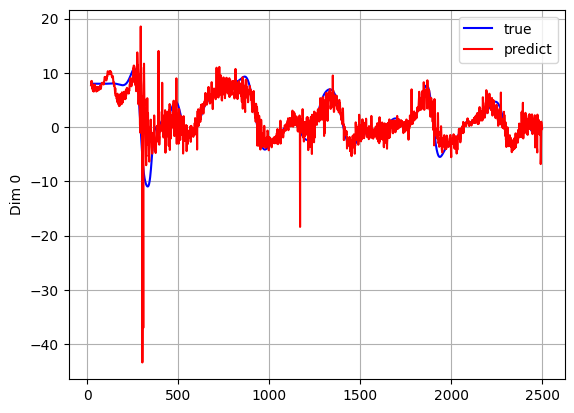

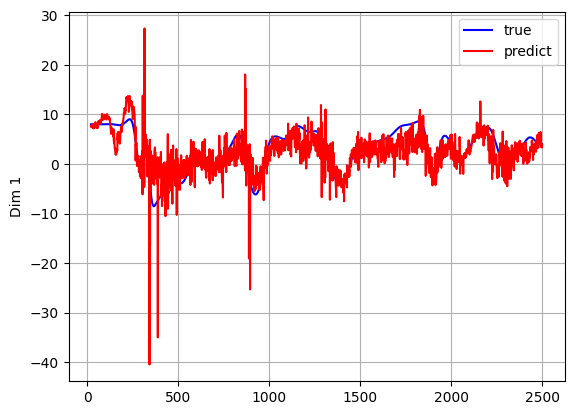

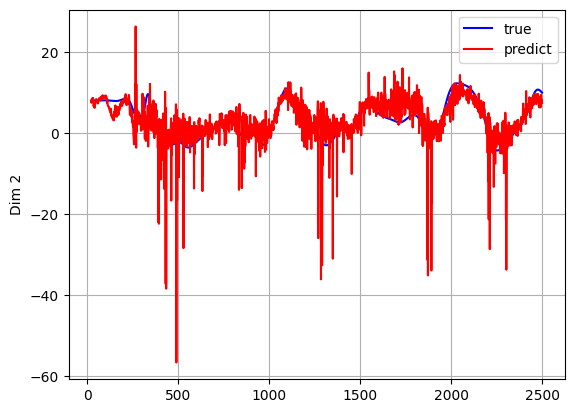

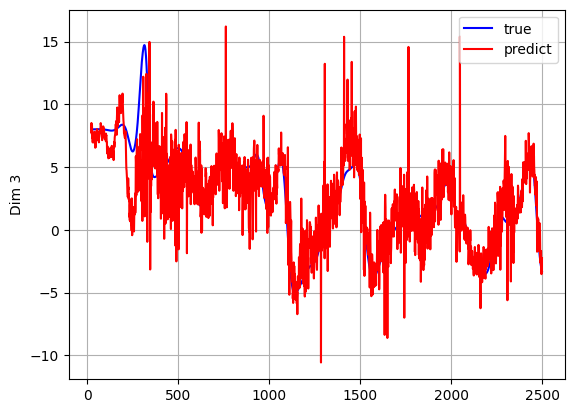

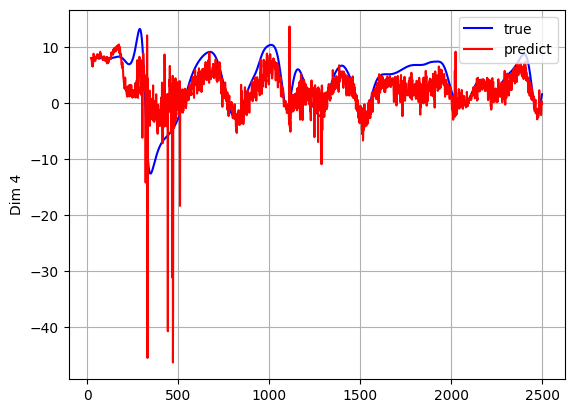

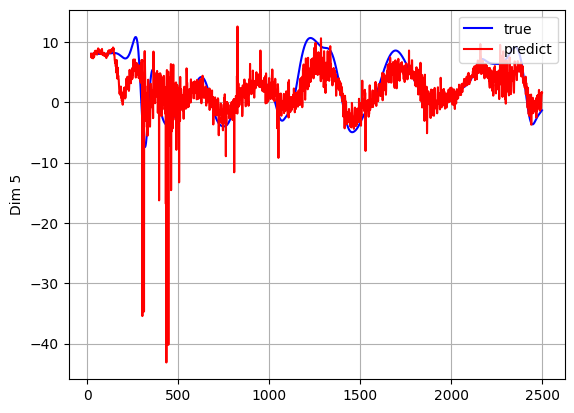

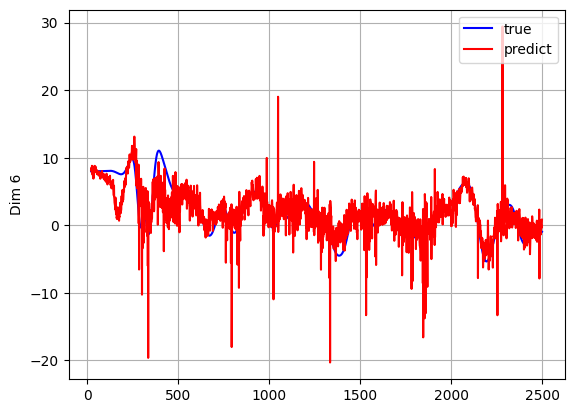

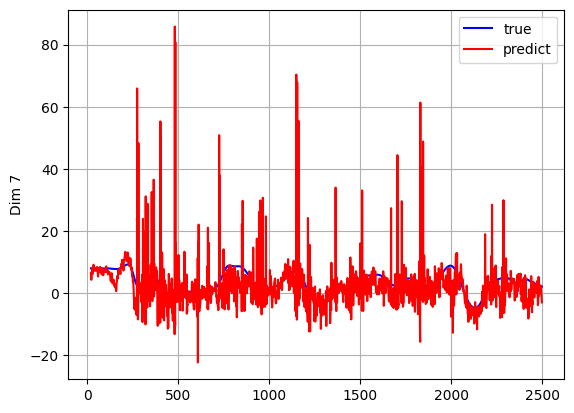

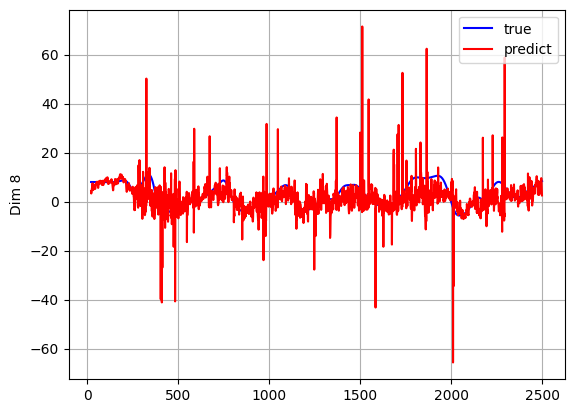

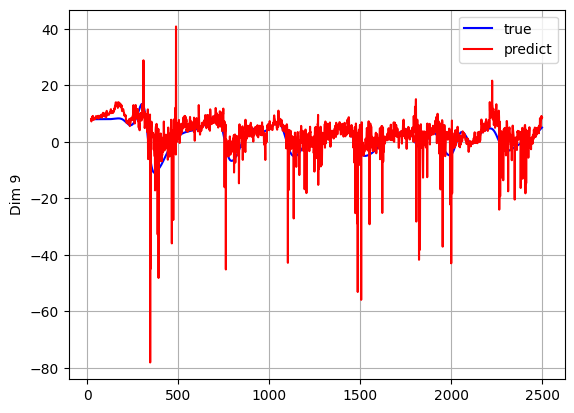

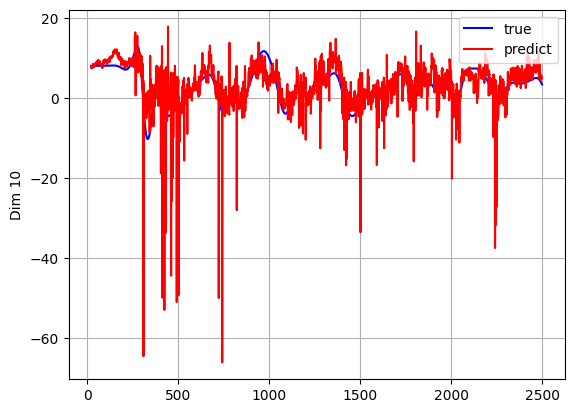

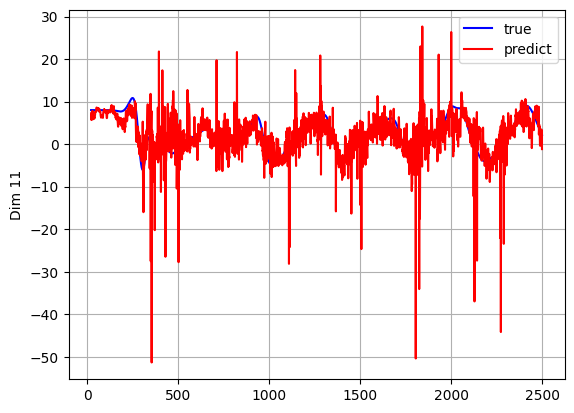

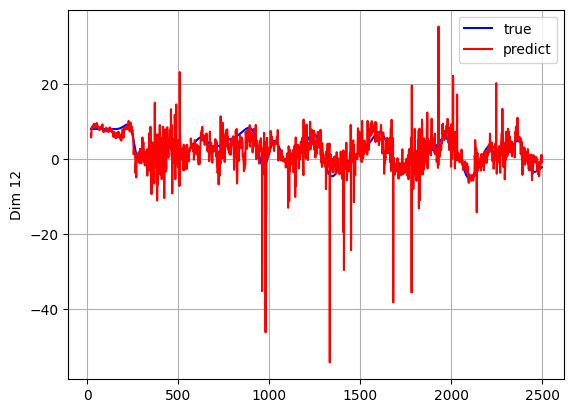

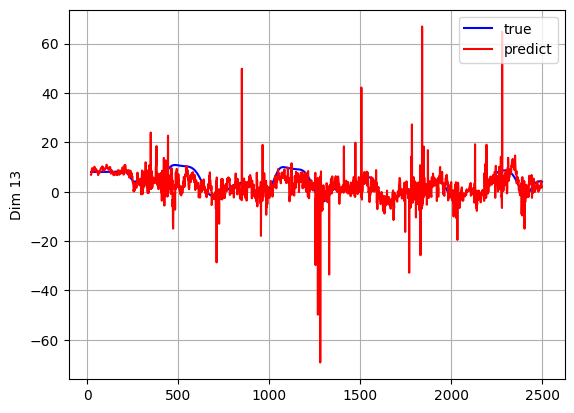

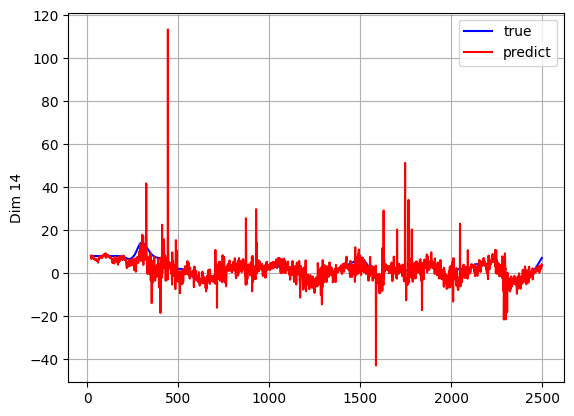

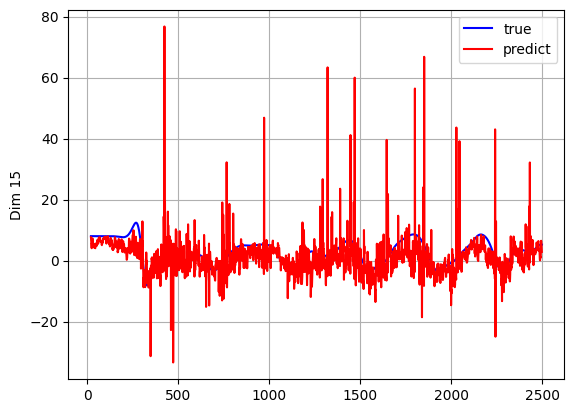

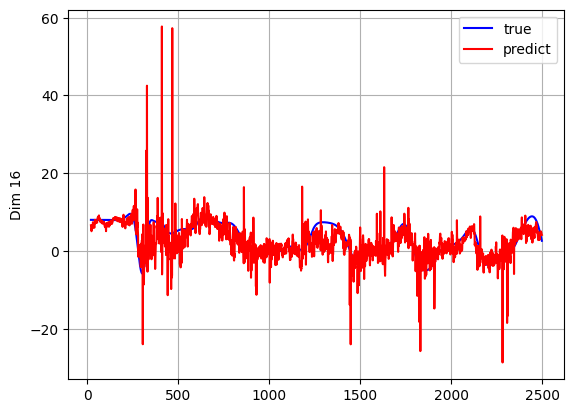

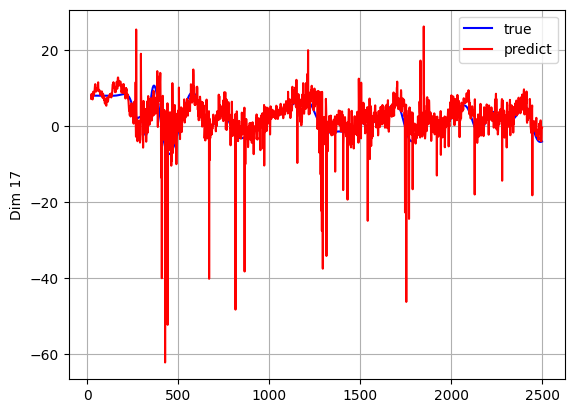

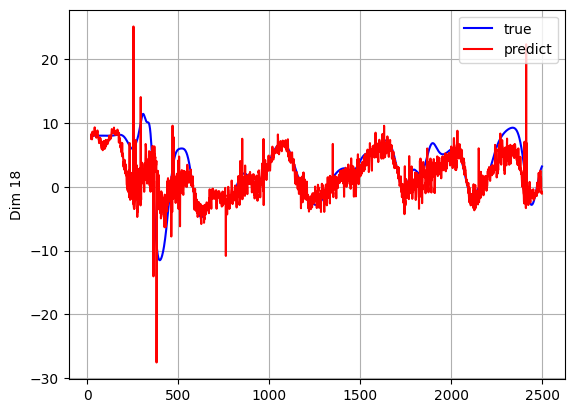

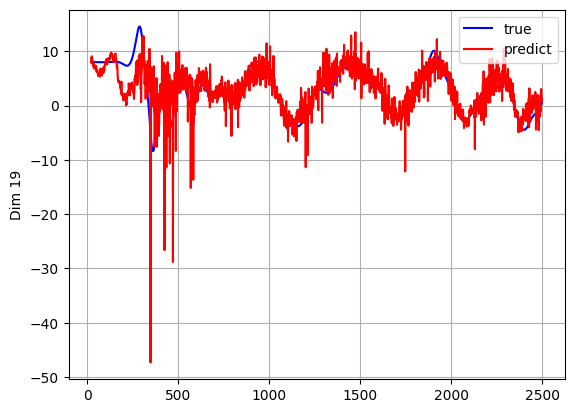

In [31]:
for i in range(20):
    #plt.scatter(np.arange(2480) + 20, y_state[: , i], label = 'predict', color = 'red', s = 0.5)
    plt.plot(np.arange(2480) + 20, sol[20: , i], label = 'true', color = 'blue')
    plt.plot(np.arange(2480) + 20, y_state[:, i], label = 'predict', color = 'red')
    plt.legend(loc = 'upper right')
    plt.grid(True)
    plt.ylabel('Dim ' + str(i))
    #plt.savefig('LSTM_Lorenz96_EnKF/LSTM_Lorenz96_EnKF_dim_' + str(i) + '.png')
    plt.show()

In [32]:
for i in range(9): 
    #initial_state = [F for _ in range(dim_x)]
    #initial_state[0] += 0.01
    print(i)
    t = np.linspace(0, terminal_time, total_data_size, endpoint = False)
    sol = np.loadtxt("lorenz96_20_" + str(i + 2) + ".txt", dtype = 'float64')
    sol = sol.astype(np.float32)
    test_data_ensf = torch.tensor(sol[LSTM_seq_len: , :], dtype = torch.float32).to(device)
    
    initial_state = sol[LSTM_seq_len - 1]
    initial_state += torch.randn_like(torch.from_numpy(initial_state)).numpy()
    initial_queue = sol[: LSTM_seq_len - 1]
    initial_queue += torch.randn_like(torch.from_numpy(initial_queue)).numpy()
    covariance_matrix = np.eye(dim_x) * 100
    f = ensemble_kalman_filter_LSTM.EnsembleKalmanFilter(x = initial_state, P = covariance_matrix, dim_z = dim_x, dt = time_step, 
                                                         N = ensemble_size, hx = identical_obs, fx = EnKF_forward_LSTM, 
                                                         ensemble_size = ensemble_size, LSTM_seq_len = LSTM_seq_len, 
                                                         x_queue = initial_queue)
    f.R *= 1 * obs_sigma ** 2
    f.Q *= (forward_error ** 2 + model_inher) * 1
    y_state = []
    obs_gap = 20
    consecutive_obs = 15
    do_obs = 0
    obs_state_num = 5
    for j in range(LSTM_seq_len, sol.shape[0]):
        #z = np.concatenate((np.zeros((LSTM_seq_len - 1) * dim_x), sol[i]), axis = None)
        f.predict()
        if j % obs_gap == 0:
            do_obs = consecutive_obs
        if do_obs:
            do_obs -= 1
            #z = sol[i] + np.random.multivariate_normal(np.zeros(dim_x), f.R)
            z = torch.clamp(torch.from_numpy(np.atan(sol[j]) + np.random.multivariate_normal(np.zeros(dim_x), f.R)), min = math.atan(-15), max = math.atan(15)).detach().cpu().numpy()
            non_obs_states = np.random.choice(dim_x, size = dim_x - obs_state_num, replace = False)
            z[non_obs_states] = np.atan(f.x[non_obs_states])
            f.update(z)
            #f.sigmas = torch.clamp(torch.from_numpy(f.sigmas), min = -15, max = 15).detach().cpu().numpy()
            #f.x = np.mean(f.sigmas, axis=0)
        y_state.append(f.x[-dim_x: ])
    y_state = np.array(y_state)
    df = pd.DataFrame({'MSE': np.square(y_state - sol[LSTM_seq_len: ]).mean(axis = 1)})
    df.to_csv('LSTM_Lorenz96_EnKF_partial_' + str(i + 2) + '.csv', index = False)



0
1
2
3
4
5
6
7
8


In [33]:
for i in range(10): 
    #initial_state = [F for _ in range(dim_x)]
    #initial_state[0] += 0.01
    print(i)
    t = np.linspace(0, terminal_time, total_data_size, endpoint = False)
    sol = np.loadtxt("lorenz96_20_" + str(i + 11) + ".txt", dtype = 'float64')
    sol = sol.astype(np.float32)
    test_data_ensf = torch.tensor(sol[LSTM_seq_len: , :], dtype = torch.float32).to(device)
    
    initial_state = sol[LSTM_seq_len - 1]
    initial_state += torch.randn_like(torch.from_numpy(initial_state)).numpy()
    initial_queue = sol[: LSTM_seq_len - 1]
    initial_queue += torch.randn_like(torch.from_numpy(initial_queue)).numpy()
    covariance_matrix = np.eye(dim_x) * 100
    f = ensemble_kalman_filter_LSTM.EnsembleKalmanFilter(x = initial_state, P = covariance_matrix, dim_z = dim_x, dt = time_step, 
                                                         N = ensemble_size, hx = identical_obs, fx = EnKF_forward_LSTM, 
                                                         ensemble_size = ensemble_size, LSTM_seq_len = LSTM_seq_len, 
                                                         x_queue = initial_queue)
    f.R *= 1 * obs_sigma ** 2
    f.Q *= (forward_error ** 2 + model_inher) * 1
    y_state = []
    obs_gap = 20
    consecutive_obs = 15
    do_obs = 0
    obs_state_num = 5
    for j in range(LSTM_seq_len, sol.shape[0]):
        #z = np.concatenate((np.zeros((LSTM_seq_len - 1) * dim_x), sol[i]), axis = None)
        f.predict()
        if j % obs_gap == 0:
            do_obs = consecutive_obs
        if do_obs:
            do_obs -= 1
            #z = sol[i] + np.random.multivariate_normal(np.zeros(dim_x), f.R)
            z = torch.clamp(torch.from_numpy(np.atan(sol[j]) + np.random.multivariate_normal(np.zeros(dim_x), f.R)), min = math.atan(-15), max = math.atan(15)).detach().cpu().numpy()
            non_obs_states = np.random.choice(dim_x, size = dim_x - obs_state_num, replace = False)
            z[non_obs_states] = np.atan(f.x[non_obs_states])
            f.update(z)
            #f.sigmas = torch.clamp(torch.from_numpy(f.sigmas), min = -15, max = 15).detach().cpu().numpy()
            #f.x = np.mean(f.sigmas, axis=0)
        y_state.append(f.x[-dim_x: ])
    y_state = np.array(y_state)
    df = pd.DataFrame({'MSE': np.square(y_state - sol[LSTM_seq_len: ]).mean(axis = 1)})
    df.to_csv('LSTM_Lorenz96_EnKF_partial_' + str(i + 11) + '.csv', index = False)



0
1
2
3
4
5
6
7
8
9


In [34]:
for i in range(10): 
    #initial_state = [F for _ in range(dim_x)]
    #initial_state[0] += 0.01
    print(i)
    t = np.linspace(0, terminal_time, total_data_size, endpoint = False)
    sol = np.loadtxt("lorenz96_20_" + str(i + 21) + ".txt", dtype = 'float64')
    sol = sol.astype(np.float32)
    test_data_ensf = torch.tensor(sol[LSTM_seq_len: , :], dtype = torch.float32).to(device)
    
    initial_state = sol[LSTM_seq_len - 1]
    initial_state += torch.randn_like(torch.from_numpy(initial_state)).numpy()
    initial_queue = sol[: LSTM_seq_len - 1]
    initial_queue += torch.randn_like(torch.from_numpy(initial_queue)).numpy()
    covariance_matrix = np.eye(dim_x) * 100
    f = ensemble_kalman_filter_LSTM.EnsembleKalmanFilter(x = initial_state, P = covariance_matrix, dim_z = dim_x, dt = time_step, 
                                                         N = ensemble_size, hx = identical_obs, fx = EnKF_forward_LSTM, 
                                                         ensemble_size = ensemble_size, LSTM_seq_len = LSTM_seq_len, 
                                                         x_queue = initial_queue)
    f.R *= 1 * obs_sigma ** 2
    f.Q *= (forward_error ** 2 + model_inher) * 1
    y_state = []
    obs_gap = 20
    consecutive_obs = 15
    do_obs = 0
    obs_state_num = 5
    for j in range(LSTM_seq_len, sol.shape[0]):
        #z = np.concatenate((np.zeros((LSTM_seq_len - 1) * dim_x), sol[i]), axis = None)
        f.predict()
        if j % obs_gap == 0:
            do_obs = consecutive_obs
        if do_obs:
            do_obs -= 1
            #z = sol[i] + np.random.multivariate_normal(np.zeros(dim_x), f.R)
            z = torch.clamp(torch.from_numpy(np.atan(sol[j]) + np.random.multivariate_normal(np.zeros(dim_x), f.R)), min = math.atan(-15), max = math.atan(15)).detach().cpu().numpy()
            non_obs_states = np.random.choice(dim_x, size = dim_x - obs_state_num, replace = False)
            z[non_obs_states] = np.atan(f.x[non_obs_states])
            f.update(z)
            #f.sigmas = torch.clamp(torch.from_numpy(f.sigmas), min = -15, max = 15).detach().cpu().numpy()
            #f.x = np.mean(f.sigmas, axis=0)
        y_state.append(f.x[-dim_x: ])
    y_state = np.array(y_state)
    df = pd.DataFrame({'MSE': np.square(y_state - sol[LSTM_seq_len: ]).mean(axis = 1)})
    df.to_csv('LSTM_Lorenz96_EnKF_partial_' + str(i + 21) + '.csv', index = False)



0
1
2
3
4
5
6
7
8
9


In [35]:
for i in range(10): 
    #initial_state = [F for _ in range(dim_x)]
    #initial_state[0] += 0.01
    print(i)
    t = np.linspace(0, terminal_time, total_data_size, endpoint = False)
    sol = np.loadtxt("lorenz96_20_" + str(i + 31) + ".txt", dtype = 'float64')
    sol = sol.astype(np.float32)
    test_data_ensf = torch.tensor(sol[LSTM_seq_len: , :], dtype = torch.float32).to(device)
    
    initial_state = sol[LSTM_seq_len - 1]
    initial_state += torch.randn_like(torch.from_numpy(initial_state)).numpy()
    initial_queue = sol[: LSTM_seq_len - 1]
    initial_queue += torch.randn_like(torch.from_numpy(initial_queue)).numpy()
    covariance_matrix = np.eye(dim_x) * 100
    f = ensemble_kalman_filter_LSTM.EnsembleKalmanFilter(x = initial_state, P = covariance_matrix, dim_z = dim_x, dt = time_step, 
                                                         N = ensemble_size, hx = identical_obs, fx = EnKF_forward_LSTM, 
                                                         ensemble_size = ensemble_size, LSTM_seq_len = LSTM_seq_len, 
                                                         x_queue = initial_queue)
    f.R *= 1 * obs_sigma ** 2
    f.Q *= (forward_error ** 2 + model_inher) * 1
    y_state = []
    obs_gap = 20
    consecutive_obs = 15
    do_obs = 0
    obs_state_num = 5
    for j in range(LSTM_seq_len, sol.shape[0]):
        #z = np.concatenate((np.zeros((LSTM_seq_len - 1) * dim_x), sol[i]), axis = None)
        f.predict()
        if j % obs_gap == 0:
            do_obs = consecutive_obs
        if do_obs:
            do_obs -= 1
            #z = sol[i] + np.random.multivariate_normal(np.zeros(dim_x), f.R)
            z = torch.clamp(torch.from_numpy(np.atan(sol[j]) + np.random.multivariate_normal(np.zeros(dim_x), f.R)), min = math.atan(-15), max = math.atan(15)).detach().cpu().numpy()
            non_obs_states = np.random.choice(dim_x, size = dim_x - obs_state_num, replace = False)
            z[non_obs_states] = np.atan(f.x[non_obs_states])
            f.update(z)
            #f.sigmas = torch.clamp(torch.from_numpy(f.sigmas), min = -15, max = 15).detach().cpu().numpy()
            #f.x = np.mean(f.sigmas, axis=0)
        y_state.append(f.x[-dim_x: ])
    y_state = np.array(y_state)
    df = pd.DataFrame({'MSE': np.square(y_state - sol[LSTM_seq_len: ]).mean(axis = 1)})
    df.to_csv('LSTM_Lorenz96_EnKF_partial_' + str(i + 31) + '.csv', index = False)



0
1
2
3
4
5
6
7
8
9


In [36]:
df_list = []
for i in range(40):
    df_list.append(pd.read_csv('LSTM_Lorenz96_EnKF_partial_' + str(i + 1) + '.csv'))
df = sum(df_list) / 40

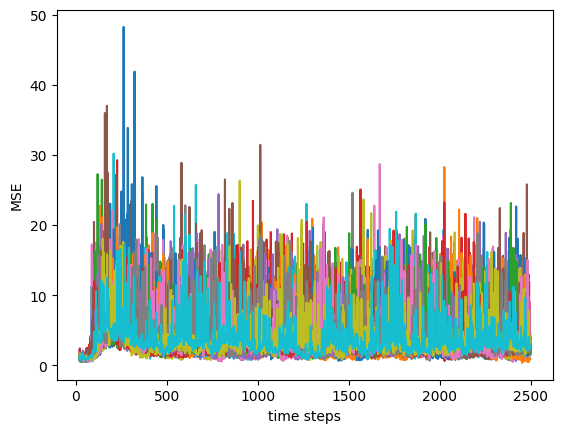

In [43]:
for i in range(40):
    plt.plot(np.arange(2480) + 20, np.array(df_list[i].apply(np.sqrt)['MSE']))
    plt.ylabel("MSE")
    plt.xlabel("time steps")
plt.savefig('LSTM_Lorenz96_EnKF_MSE_partial.png', bbox_inches='tight')
plt.show()

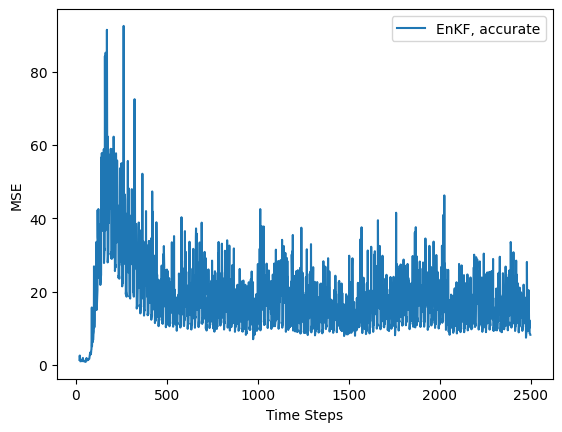

In [44]:
plt.plot(np.arange(2480) + 20, np.array(df['MSE']), label = 'EnKF, accurate')
plt.ylabel('MSE')
plt.xlabel('Time Steps')
plt.legend(loc = 'upper right')
plt.savefig('LSTM_Lorenz96_EnKF_partial_MSE.png', bbox_inches='tight')
plt.show()

In [45]:
df.to_csv('LSTM_Lorenz96_EnKF_accurate_partial_MSE.csv', index = False)